# P1 multinomial vs One-vs-Rest LR
P1의 structured+26 enrichment 입력을 고정한다. 목적함수만 26개 binary OVR LR로 바꿔 Macro F1과의 정렬 가능성을 확인한다. threshold·offset·blend 탐색은 하지 않는다.

In [1]:
from pathlib import Path
import subprocess, sys
ROOT=next(p for p in (Path.cwd(),*Path.cwd().parents) if (p/'experiments/gs/notebooks/exp_model_002/common/run_p1_axis.py').exists())
RUNNER=ROOT/'experiments/gs/notebooks/exp_model_002/common/run_p1_axis.py'; RESULT=RUNNER.parent.parent/'result'
RUN_ID='exp-p1-ovr-01'; SEED=42; RUN_EXPERIMENT=True
# 고정 LR: lbfgs, C=.07, max_iter=2000, class_weight=balanced

row-local mutation cache: 100%|██████████| 4384/4384 [00:11<00:00, 390.48it/s]


          variant  oof_macro_f1  feature_count  convergence_warning_count  leakage_check  nan_as_mutation_count  runtime_seconds
P1 multinomial LR       0.52755         8201.2                          0           True                      0        57.138851
              ovr       0.52145         8201.2                          0           True                      0        57.146821


,variant,oof_macro_f1,feature_count,convergence_warning_count,leakage_check,nan_as_mutation_count,runtime_seconds
0,P1 multinomial LR,0.52755,8201.2,0,True,0,57.138851
1,ovr,0.52145,8201.2,0,True,0,57.146821


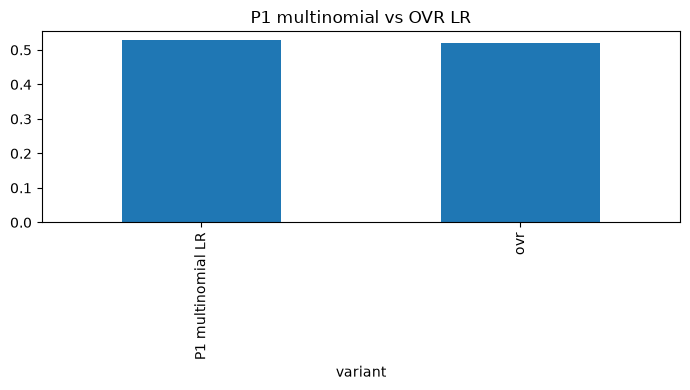

In [2]:
if RUN_EXPERIMENT: subprocess.run([sys.executable,str(RUNNER),'--axis','ovr','--seed',str(SEED),'--run-id',RUN_ID],check=True)
import pandas as pd, matplotlib.pyplot as plt
s=pd.read_csv(RESULT/f'{RUN_ID}_seed{SEED}_summary.csv'); assert s.leakage_check.all() and s.nan_as_mutation_count.eq(0).all(); display(s)
s.set_index('variant').oof_macro_f1.plot.bar(figsize=(7,4),title='P1 multinomial vs OVR LR'); plt.tight_layout(); plt.show()